In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import lightgbm as lgb
import joblib
import os

df = pd.read_csv("data/failure_corpus.csv")
print(df.shape)
df.head()

(2000, 18)


,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,account_balance_usd,cvv_retry_count,velocity_score,merchant_risk_score,time_of_day_hour,day_of_week,error_text,category,retry_action_taken,delay_before_retry_min,outcome
0,txn_10651,25.68,Online Retail,RuPay,OTP,Online,Mac,6741.65,0,17.9,29.0,1,2,Card flagged for review - high risk score,risk_block,retry_same_card,0,failed_again
1,txn_02042,161.48,Travel,Visa,No Authentication,Online,Windows PC,1914.68,0,19.8,28.1,10,6,Do Not Honour - Insufficient funds,insufficient_funds,retry_upi,30,failed_again
2,txn_08669,46.46,Streaming,RuPay,PIN,POS,Smart Watch,66252.53,0,0.4,23.5,23,2,Card flagged for review - high risk score,risk_block,retry_same_card,0,failed_again
3,txn_01115,40.74,Online Retail,Mastercard,3D Secure,Contactless,iPhone,4357.41,0,34.8,49.6,14,2,Network error - request could not be completed,network_error,retry_same_card,0,recovered
4,txn_13903,12.16,Fuel,Amex,3D Secure,Contactless,ATM Machine,6699.26,0,30.7,27.9,0,4,Bank server did not respond in time,bank_timeout,no_retry,30,failed_again


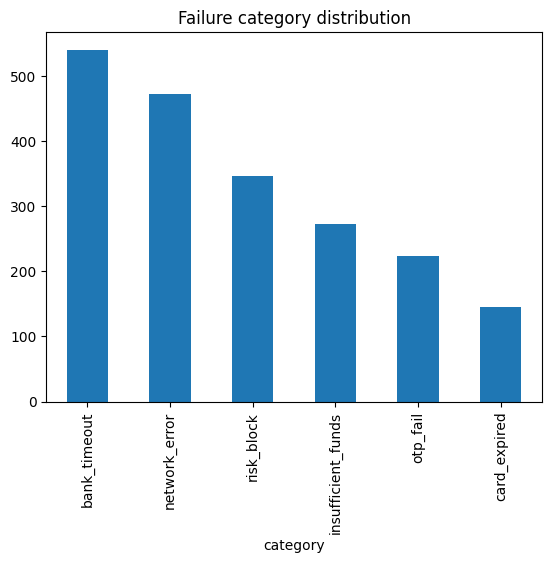

In [14]:

df["category"].value_counts().plot(kind="bar", title="Failure category distribution")
plt.show()

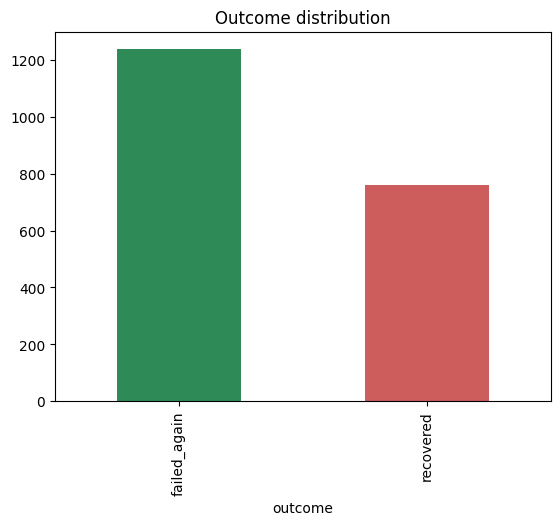

In [15]:

df["outcome"].value_counts().plot(kind="bar", title="Outcome distribution", color=["seagreen","indianred"])
plt.show()

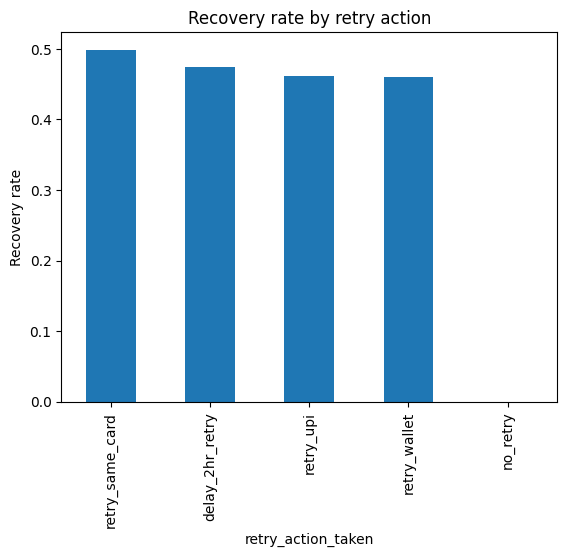

In [16]:

recovery_by_action = df.groupby("retry_action_taken")["outcome"].apply(lambda s: (s=="recovered").mean()).sort_values(ascending=False)
recovery_by_action.plot(kind="bar", title="Recovery rate by retry action")
plt.ylabel("Recovery rate")
plt.show()

In [32]:
df["outcome"].value_counts()

outcome
failed_again    1238
recovered        762
Name: count, dtype: int64

In [34]:

counts = df.groupby(["retry_action_taken", "outcome"]).size().unstack(fill_value=0)


for method, (failures, recovered) in zip(counts.index, counts.values):
    print(f"{method}: Failures={failures}, Recovered={recovered}")


delay_2hr_retry: Failures=216, Recovered=195
no_retry: Failures=393, Recovered=0
retry_same_card: Failures=212, Recovered=211
retry_upi: Failures=216, Recovered=185
retry_wallet: Failures=201, Recovered=171


In [31]:
recovery_rate_max_for_method= df.groupby("retry_action_taken")["outcome"].apply(lambda x: sum(1 for x in df["outcome"] if x=="recovered"))
print(recovery_rate_max_for_method)

retry_action_taken
delay_2hr_retry    762
no_retry           762
retry_same_card    762
retry_upi          762
retry_wallet       762
Name: outcome, dtype: int64


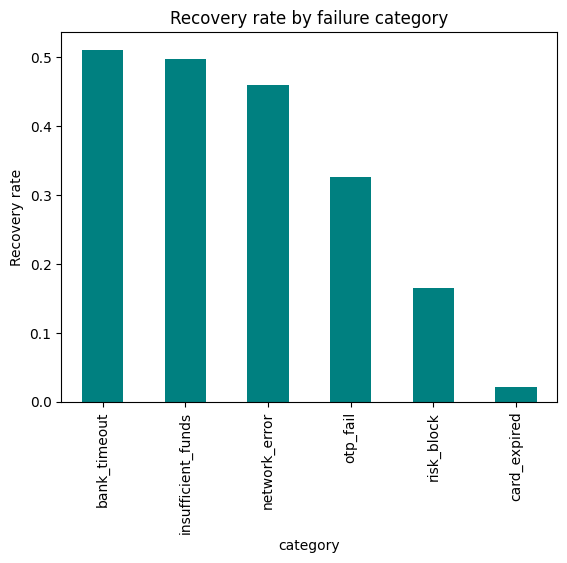

In [17]:

recovery_by_category = df.groupby("category")["outcome"].apply(lambda s: (s=="recovered").mean()).sort_values(ascending=False)
recovery_by_category.plot(kind="bar", title="Recovery rate by failure category", color="teal")
plt.ylabel("Recovery rate")
plt.show()

In [18]:
target = (df["outcome"] == "recovered").astype(int)

categorical_cols = [
    "category", "retry_action_taken", "auth_method",
    "channel", "card_type", "merchant_category",
]

numeric_cols = [
    "amount_usd", "account_balance_usd", "cvv_retry_count",
    "velocity_score", "merchant_risk_score", "time_of_day_hour",
    "day_of_week", "delay_before_retry_min",
]

features = df[categorical_cols + numeric_cols].copy()


encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    features[col] = le.fit_transform(features[col].astype(str))
    encoders[col] = le

features.head()

,category,retry_action_taken,auth_method,channel,card_type,merchant_category,amount_usd,account_balance_usd,cvv_retry_count,velocity_score,merchant_risk_score,time_of_day_hour,day_of_week,delay_before_retry_min
0,5,2,3,3,3,7,25.68,6741.65,0,17.9,29.0,1,2,0
1,2,3,2,3,4,10,161.48,1914.68,0,19.8,28.1,10,6,30
2,5,2,4,4,3,9,46.46,66252.53,0,0.4,23.5,23,2,0
3,3,2,0,1,2,7,40.74,4357.41,0,34.8,49.6,14,2,0
4,0,1,0,1,0,2,12.16,6699.26,0,30.7,27.9,0,4,30


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train positive rate:", y_train.mean().round(3))
print("Test positive rate:", y_test.mean().round(3))

Train: (1600, 14) Test: (400, 14)
Train positive rate: 0.381
Test positive rate: 0.38


In [20]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)],
)

[LightGBM] [Info] Number of positive: 610, number of negative: 990
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1097
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 30 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=6,
               n_estimators=300, random_state=42)

In [21]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=["failed_again", "recovered"]))

Accuracy: 0.7
ROC-AUC : 0.7915

              precision    recall  f1-score   support

failed_again       0.89      0.59      0.71       248
   recovered       0.57      0.88      0.69       152

    accuracy                           0.70       400
   macro avg       0.73      0.73      0.70       400
weighted avg       0.77      0.70      0.70       400



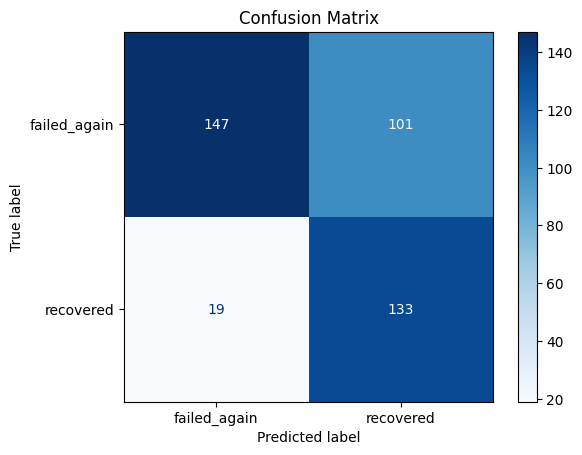

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["failed_again", "recovered"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

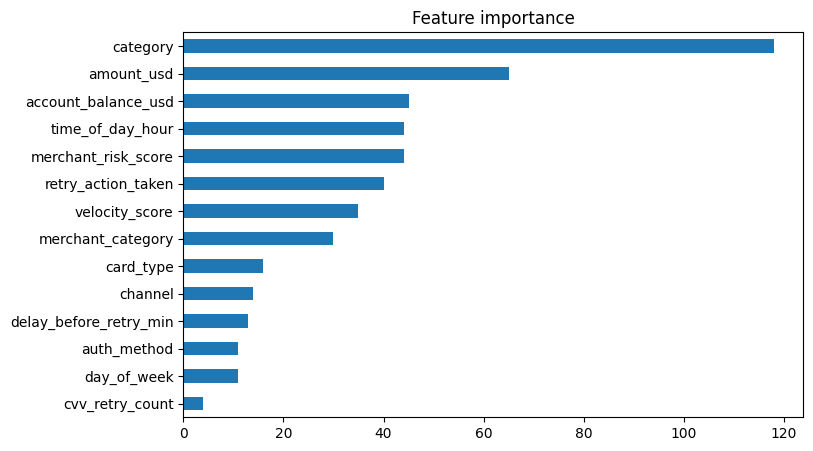

category                  118
amount_usd                 65
account_balance_usd        45
time_of_day_hour           44
merchant_risk_score        44
retry_action_taken         40
velocity_score             35
merchant_category          30
card_type                  16
channel                    14
delay_before_retry_min     13
auth_method                11
day_of_week                11
cvv_retry_count             4
dtype: int32

In [23]:
importance = pd.Series(model.feature_importances_, index=features.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature importance")
plt.gca().invert_yaxis()
plt.show()
importance

In [24]:

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/retry_recovery_lgbm.pkl")
joblib.dump(encoders, "models/label_encoders.pkl")
joblib.dump(list(features.columns), "models/feature_columns.pkl")

print("Saved model, encoders, and feature column order to models/")


from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)


target_precision = 0.75
candidates = [(t, p, r) for p, r, t in zip(precisions, recalls, thresholds) if p >= target_precision]

if candidates:
    best_t, best_p, best_r = candidates[0]  
    print(f"Threshold={best_t:.3f} -> precision={best_p:.3f}, recall={best_r:.3f}")
else:
    print(f"No threshold reaches {target_precision} precision; max precision achievable: {precisions.max():.3f}")


for t in [0.5, 0.6, 0.65, 0.7]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"\nThreshold {t}:")
    print(classification_report(y_test, y_pred_t, target_names=["failed_again", "recovered"]))

Saved model, encoders, and feature column order to models/
Threshold=0.691 -> precision=0.750, recall=0.079

Threshold 0.5:
              precision    recall  f1-score   support

failed_again       0.89      0.59      0.71       248
   recovered       0.57      0.88      0.69       152

    accuracy                           0.70       400
   macro avg       0.73      0.73      0.70       400
weighted avg       0.77      0.70      0.70       400


Threshold 0.6:
              precision    recall  f1-score   support

failed_again       0.79      0.73      0.76       248
   recovered       0.61      0.69      0.65       152

    accuracy                           0.71       400
   macro avg       0.70      0.71      0.70       400
weighted avg       0.72      0.71      0.72       400


Threshold 0.65:
              precision    recall  f1-score   support

failed_again       0.66      0.92      0.77       248
   recovered       0.64      0.24      0.35       152

    accuracy             